# Breast Cancer Patient's Vital Status Prediction

This notebook aims to predict the **Vital Status** of breast cancer patients using the METABRIC dataset. We will follow a similar workflow to the preliminary breast cancer prediction analysis, focusing on data cleaning, exploratory data analysis, and machine learning model development.

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Set visual style
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)

## 1. Data Loading and Initial Inspection

In [23]:
# Load the dataset
df = pd.read_csv('data/Breast Cancer METABRIC.csv')
df = df.drop(columns=["Overall Survival Status"])

# Display basic info
print(f"Dataset Shape: {df.shape}")
df.head()

Dataset Shape: (2509, 33)


,Patient ID,Age at Diagnosis,Type of Breast Surgery,Cancer Type,Cancer Type Detailed,Cellularity,Chemotherapy,Pam50 + Claudin-low subtype,Cohort,ER status measured by IHC,...,Overall Survival (Months),PR Status,Radio Therapy,Relapse Free Status (Months),Relapse Free Status,Sex,3-Gene classifier subtype,Tumor Size,Tumor Stage,Patient's Vital Status
0,MB-0000,75.65,Mastectomy,Breast Cancer,Breast Invasive Ductal Carcinoma,NaN,No,claudin-low,1.0,Positve,...,140.500000,Negative,Yes,138.65,Not Recurred,Female,ER-/HER2-,22.0,2.0,Living
1,MB-0002,43.19,Breast Conserving,Breast Cancer,Breast Invasive Ductal Carcinoma,High,No,LumA,1.0,Positve,...,84.633333,Positive,Yes,83.52,Not Recurred,Female,ER+/HER2- High Prolif,10.0,1.0,Living
2,MB-0005,48.87,Mastectomy,Breast Cancer,Breast Invasive Ductal Carcinoma,High,Yes,LumB,1.0,Positve,...,163.700000,Positive,No,151.28,Recurred,Female,NaN,15.0,2.0,Died of Disease
3,MB-0006,47.68,Mastectomy,Breast Cancer,Breast Mixed Ductal and Lobular Carcinoma,Moderate,Yes,LumB,1.0,Positve,...,164.933333,Positive,Yes,162.76,Not Recurred,Female,NaN,25.0,2.0,Living
4,MB-0008,76.97,Mastectomy,Breast Cancer,Breast Mixed Ductal and Lobular Carcinoma,High,Yes,LumB,1.0,Positve,...,41.366667,Positive,Yes,18.55,Recurred,Female,ER+/HER2- High Prolif,40.0,2.0,Died of Disease


In [24]:
# Description of the Dataset showing the Mean, Median, Mode, Standard Deviation, Minimum and Maximum Values
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age at Diagnosis,2498.0,60.420300,13.032997,21.93,50.920000,61.110000,70.000000,96.29
Cohort,2498.0,2.900320,1.962216,1.00,1.000000,3.000000,4.000000,9.00
Neoplasm Histologic Grade,2388.0,2.412060,0.649363,1.00,2.000000,3.000000,3.000000,3.00
Lymph nodes examined positive,2243.0,1.950513,4.017774,0.00,0.000000,0.000000,2.000000,45.00
Mutation Count,2357.0,5.578702,3.967967,1.00,3.000000,5.000000,7.000000,80.00
Nottingham prognostic index,2287.0,4.028787,1.189092,1.00,3.048000,4.044000,5.040000,7.20
Overall Survival (Months),1981.0,125.244271,76.111772,0.00,60.866667,116.466667,185.133333,355.20
Relapse Free Status (Months),2388.0,108.842487,76.519494,0.00,40.560000,99.095000,167.640000,384.21
Tumor Size,2360.0,26.220093,15.370883,1.00,17.000000,22.410000,30.000000,182.00
Tumor Stage,1788.0,1.713647,0.655307,0.00,1.000000,2.000000,2.000000,4.00


## 2. Data Cleaning

We need to handle missing values and remove columns that aren't useful for prediction (like patient IDs).

In [25]:
# Drop rows with missing target variable
target_col = "Patient's Vital Status"
df = df.dropna(subset=[target_col])

# Drop Patient ID as it's just an identifier
if 'Patient ID' in df.columns:
    df = df.drop(columns=['Patient ID'])

# Check for other missing values
missing_percent = (df.isnull().sum() / len(df)) * 100
missing_cols = missing_percent[missing_percent > 0].sort_values(ascending=False)
print("Percentage of missing values in each column:")
print(missing_cols)

Percentage of missing values in each column:
Tumor Stage                       26.010101
3-Gene classifier subtype         10.959596
Mutation Count                     6.111111
Primary Tumor Laterality           5.606061
Neoplasm Histologic Grade          4.444444
Lymph nodes examined positive      3.838384
Cellularity                        3.232323
Tumor Other Histologic Subtype     2.222222
ER status measured by IHC          2.171717
Type of Breast Surgery             1.313131
Tumor Size                         1.313131
Pam50 + Claudin-low subtype        0.050505
Chemotherapy                       0.050505
Integrative Cluster                0.050505
Inferred Menopausal State          0.050505
Hormone Therapy                    0.050505
HER2 Status                        0.050505
HER2 status measured by SNP6       0.050505
Nottingham prognostic index        0.050505
PR Status                          0.050505
Radio Therapy                      0.050505
dtype: float64


### 2.1 Imputing Missing Values

We will use the median for numerical columns and the mode for categorical columns.

In [26]:
# Identify numerical and categorical columns
numerical_cols = df.select_dtypes(include=['float64', 'int64']).columns
categorical_cols = df.select_dtypes(include=['object']).columns

# Impute numerical with median
for col in numerical_cols:
    df[col] = df[col].fillna(df[col].median())

# Impute categorical with mode
for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

print(f"Missing values remaining: {df.isnull().sum().sum()}")

Missing values remaining: 0


/tmp/ipykernel_2384238/4116024821.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=['object']).columns


## 3. Exploratory Data Analysis (EDA)

Let's look at the distribution of the target variable and some key correlations.

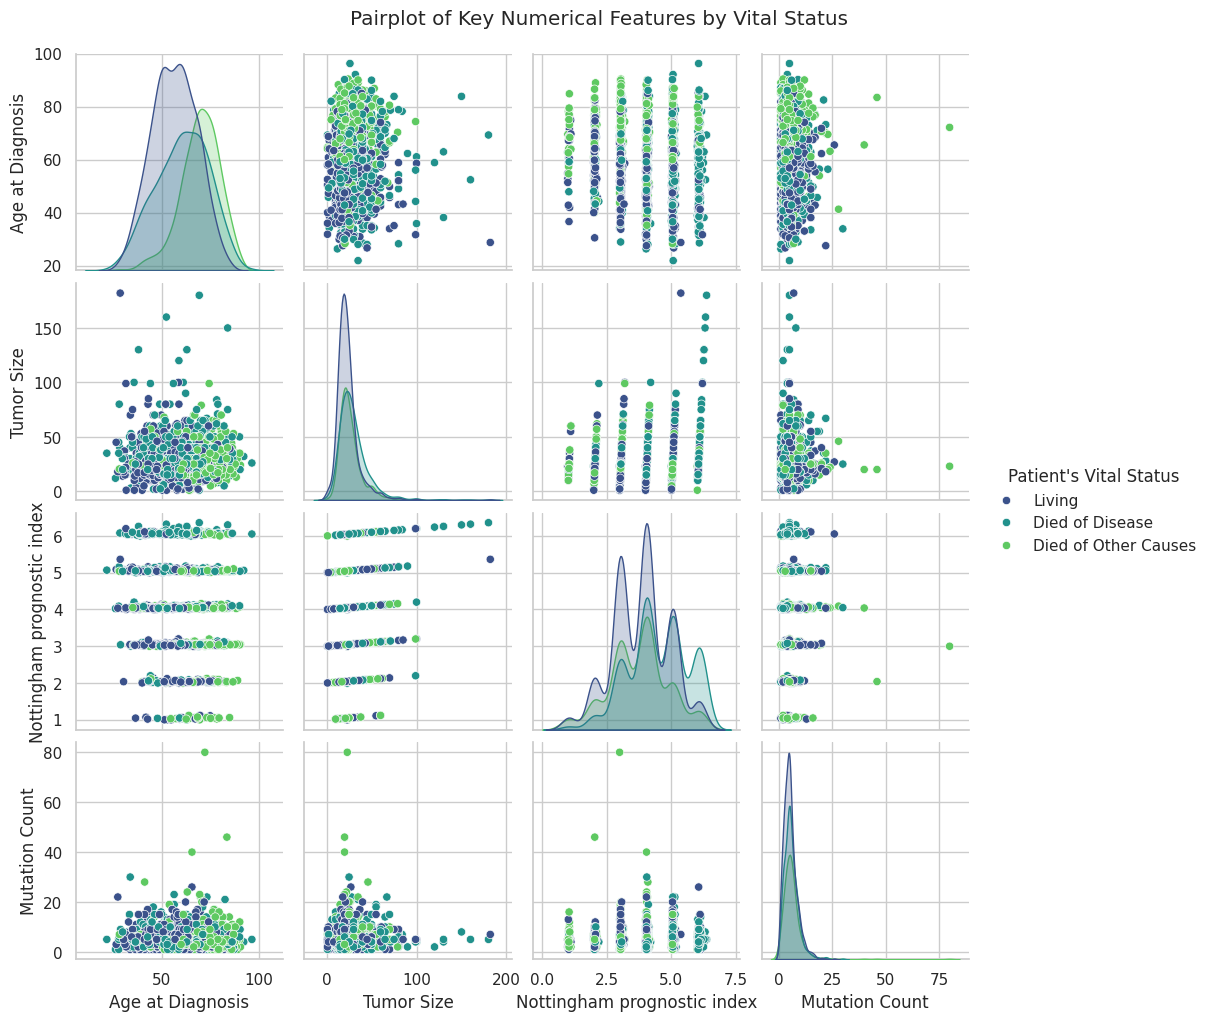

In [27]:
cols_to_pair = [target_col, 'Age at Diagnosis', 'Tumor Size', 'Nottingham prognostic index', 'Mutation Count']
sns.pairplot(df[cols_to_pair].dropna(), hue=target_col, palette='viridis')
plt.suptitle('Pairplot of Key Numerical Features by Vital Status', y=1.02)
plt.show()

/tmp/ipykernel_2384238/1261140129.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=target_col, data=df, palette='viridis')


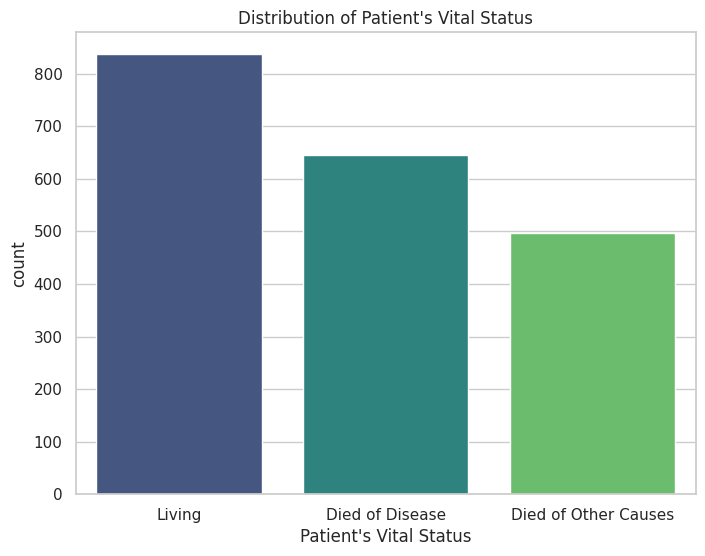

/tmp/ipykernel_2384238/1261140129.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=target_col, y='Age at Diagnosis', data=df, palette='magma')


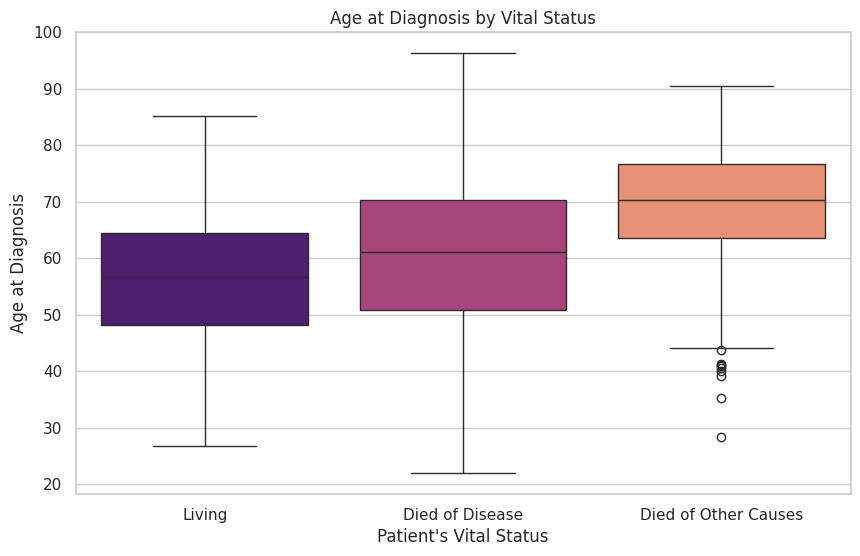

In [28]:
# Target distribution
plt.figure(figsize=(8, 6))
sns.countplot(x=target_col, data=df, palette='viridis')
plt.title("Distribution of Patient's Vital Status")
plt.show()

# Example: Age vs Vital Status
plt.figure(figsize=(10, 6))
sns.boxplot(x=target_col, y='Age at Diagnosis', data=df, palette='magma')
plt.title('Age at Diagnosis by Vital Status')
plt.show()

### Visualizing the distribution of all numerical columns


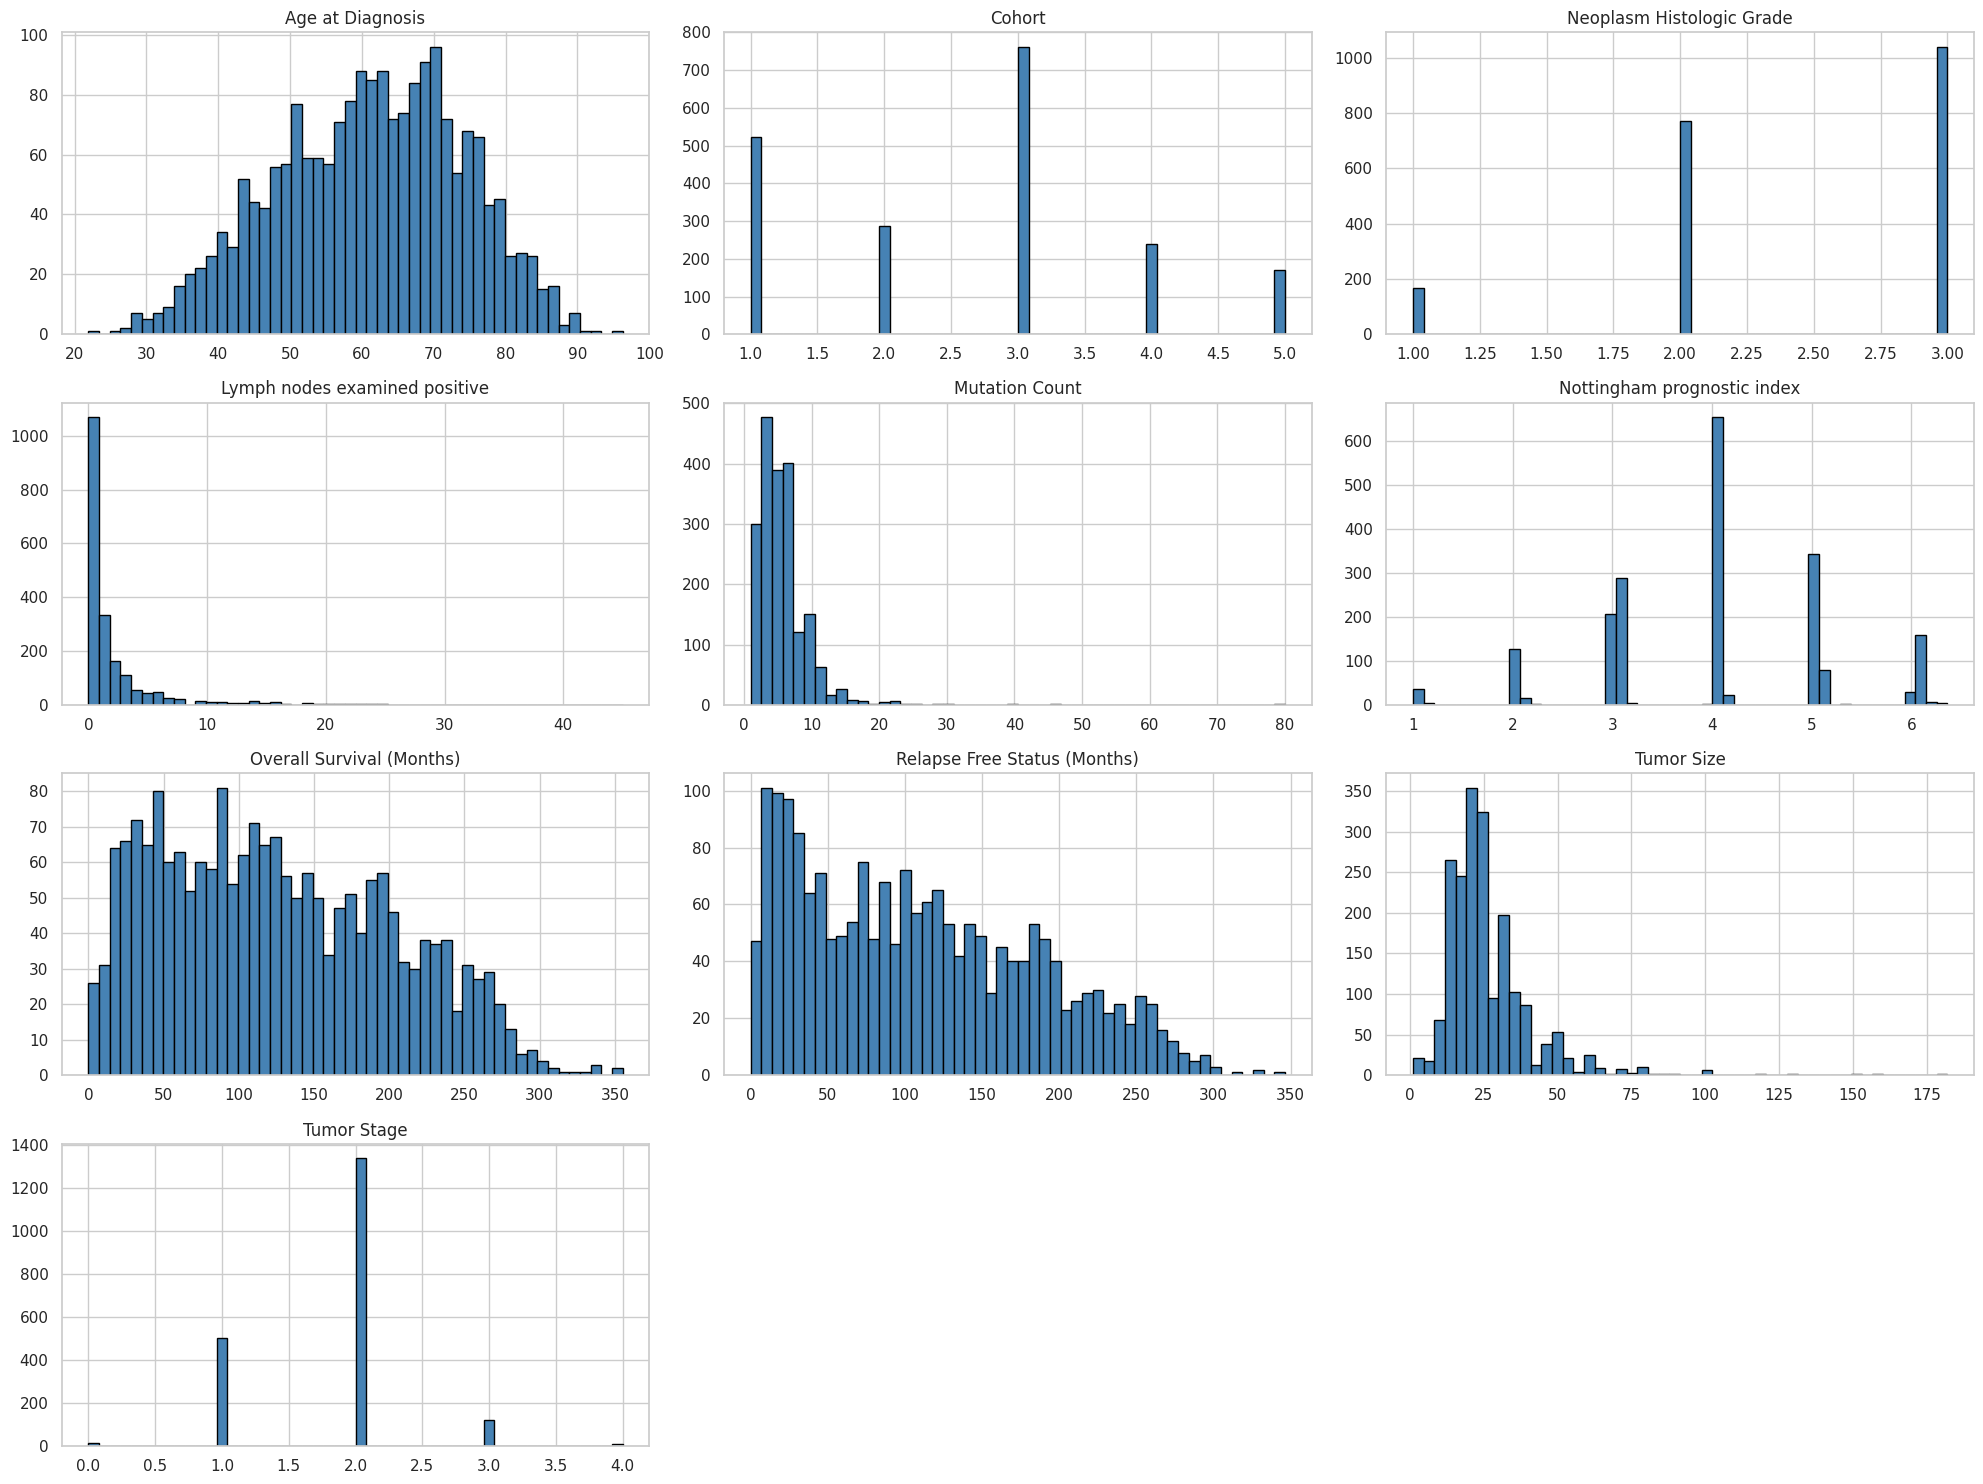

In [29]:
df.hist(bins=50, figsize=(20,15), color='steelblue', edgecolor='black')
plt.tight_layout()
plt.show()

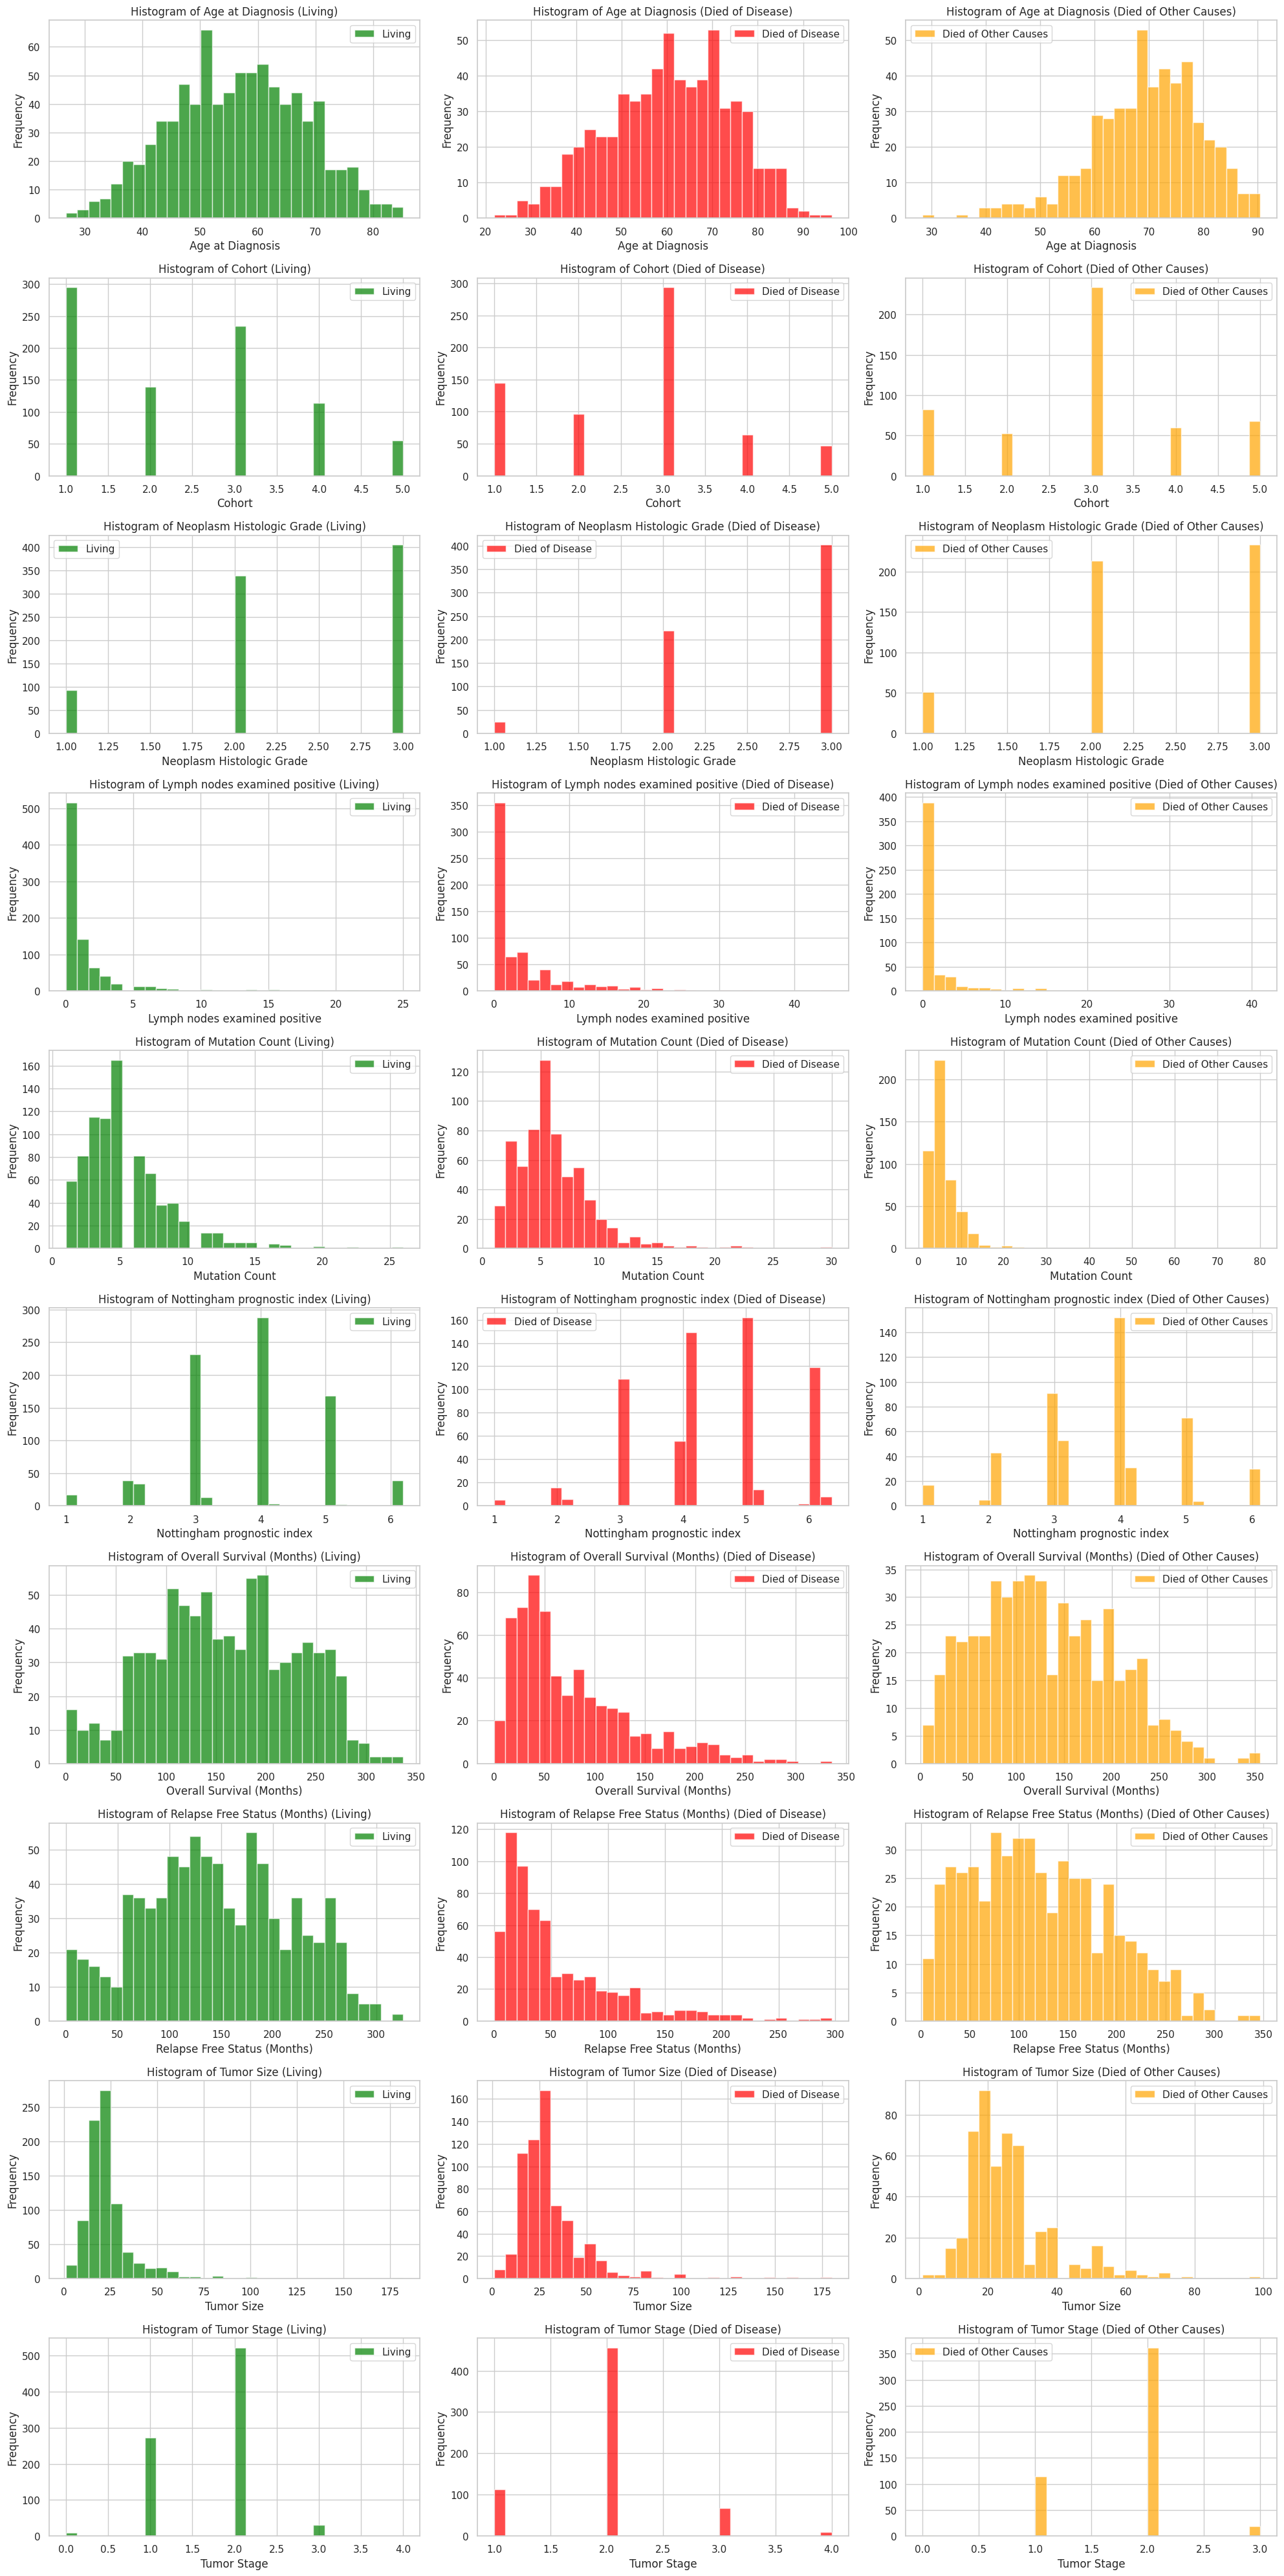

In [30]:
features = df.select_dtypes(include=['float64', 'int64']).columns.tolist()
statuses = df[target_col].unique()
colors = ['green', 'red', 'orange']

n_features = len(features)
n_cols = 3
n_rows = n_features

plt.figure(figsize=(20, 4 * n_rows))

for i, feature in enumerate(features):
    for j, status in enumerate(statuses):
        plt.subplot(n_rows, n_cols, i * n_cols + j + 1)
        data = df[df[target_col] == status][feature]
        plt.hist(data, bins=30, color=colors[j % len(colors)], alpha=0.7, label=status)
        plt.title(f'Histogram of {feature} ({status})')
        plt.xlabel(feature)
        plt.ylabel('Frequency')
        plt.legend()

plt.tight_layout()
plt.show()

/tmp/ipykernel_2384238/1162409726.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x=target_col, y=feature, data=df, palette='Set2')
/tmp/ipykernel_2384238/1162409726.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x=target_col, y=feature, data=df, palette='Set2')
/tmp/ipykernel_2384238/1162409726.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x=target_col, y=feature, data=df, palette='Set2')
/tmp/ipykernel_2384238/1162409726.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be remov

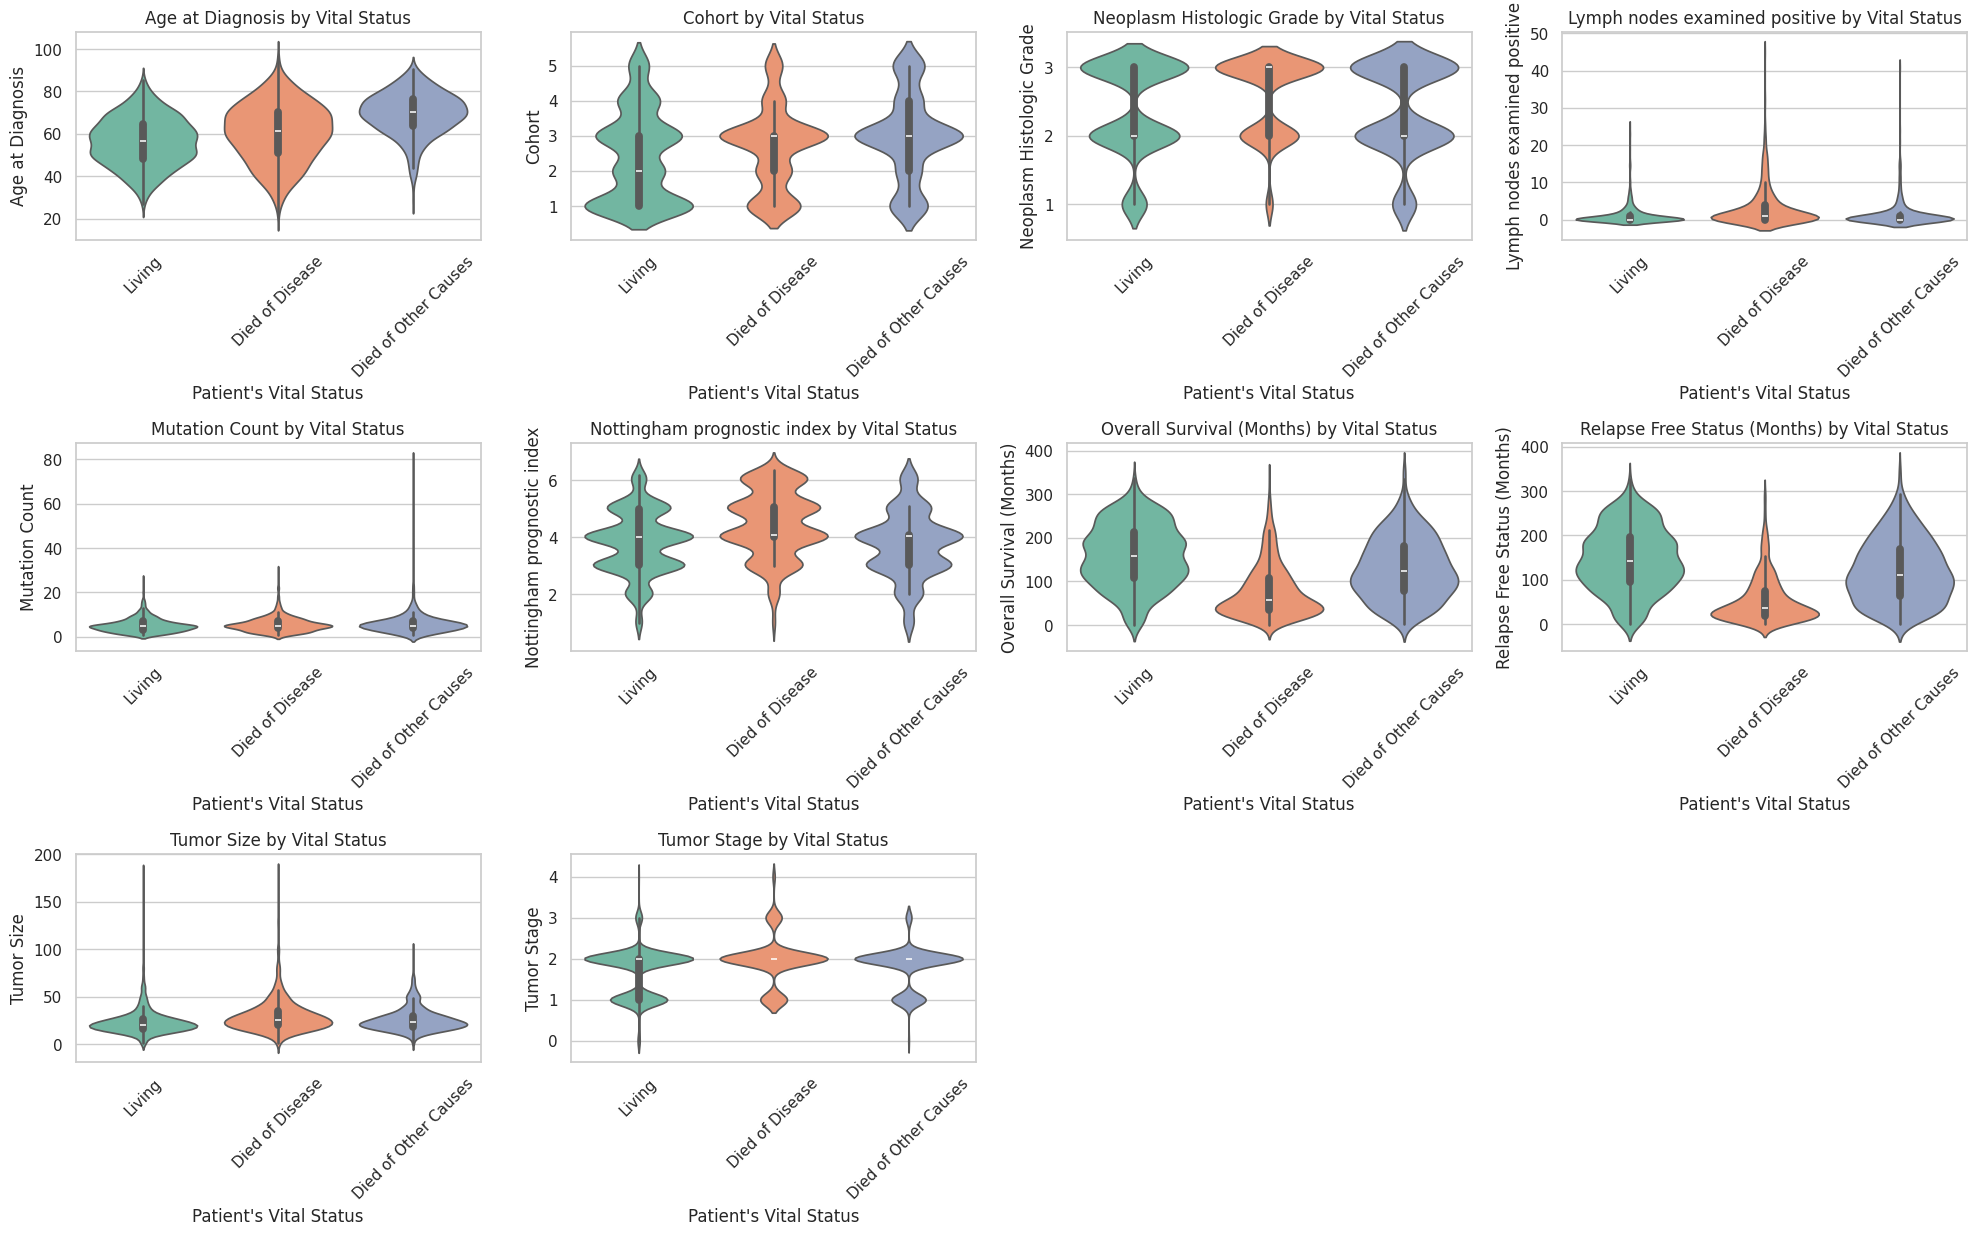

In [31]:
features_to_plot = df.select_dtypes(include=['float64', 'int64']).columns

plt.figure(figsize=(20, 15))
for i, feature in enumerate(features_to_plot, 1):
    plt.subplot(4, 4, i)
    sns.violinplot(x=target_col, y=feature, data=df, palette='Set2')
    plt.title(f'{feature} by Vital Status')
    plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

/tmp/ipykernel_2384238/1439778314.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=target_col, y=feature, data=df, palette='Set2')
/tmp/ipykernel_2384238/1439778314.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=target_col, y=feature, data=df, palette='Set2')
/tmp/ipykernel_2384238/1439778314.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=target_col, y=feature, data=df, palette='Set2')
/tmp/ipykernel_2384238/1439778314.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.

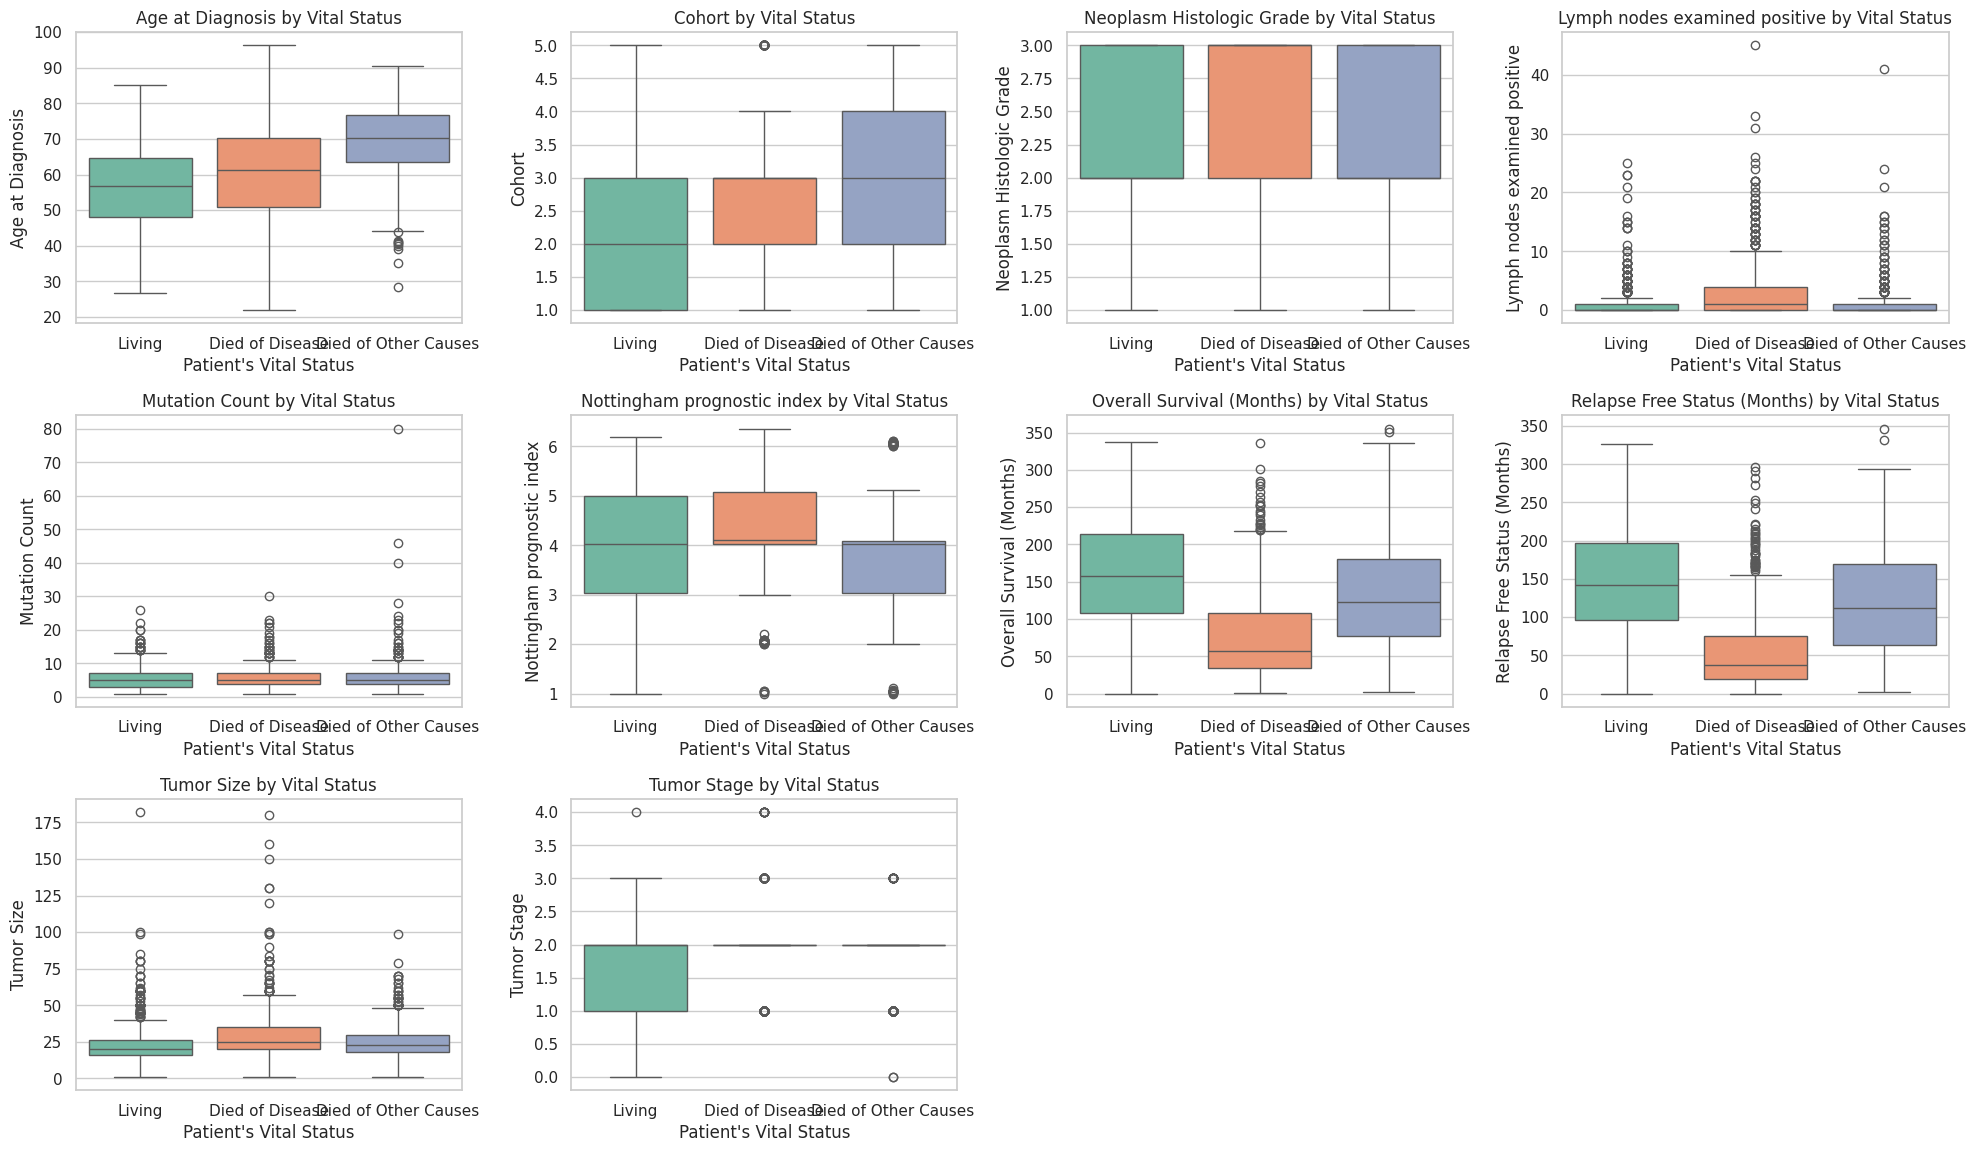

In [32]:
# Identify numerical features for plotting
numerical_features = df.select_dtypes(include=['float64', 'int64']).columns
features_to_plot = [f for f in numerical_features if f != target_col]

plt.figure(figsize=(20, 15))
for i, feature in enumerate(features_to_plot, 1):
    plt.subplot(4, 4, i)  # Adjusting grid for numerical features
    sns.boxplot(x=target_col, y=feature, data=df, palette='Set2')
    plt.title(f'{feature} by Vital Status')
plt.tight_layout()
plt.show()
# We can see the outliers which we'll definitely have to remove

## 4. Preprocessing for Machine Learning

Encoding categorical variables and scaling numerical features.

In [33]:
# Encode categorical variables
le = LabelEncoder()
for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

# Define X and y
X = df.drop(columns=[target_col])
y = df[target_col]

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Preprocessing Complete.")

Preprocessing Complete.


## 5. Model Development: Random Forest Classifier

We will train a Random Forest model, consistent with the original notebook's approach.

In [34]:
# Train Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_scaled, y_train)

# Make Predictions
y_pred = rf_model.predict(X_test_scaled)

print("Model Training Complete.")

Model Training Complete.


## 6. Evaluation

Assessing the model's performance using classification metrics and a confusion matrix.

Accuracy Score: 0.8030

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.98      0.92       142
           1       0.69      0.53      0.60        91
           2       0.79      0.80      0.80       163

    accuracy                           0.80       396
   macro avg       0.78      0.77      0.77       396
weighted avg       0.79      0.80      0.79       396



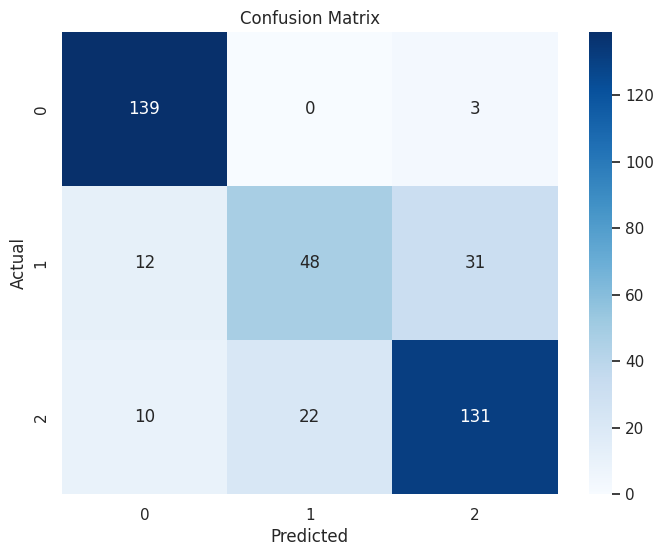

In [35]:
# Metrics
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy Score: {accuracy:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Confusion Matrix
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

## 7. Feature Importance

Visualizing which features contribute most to the prediction.

/tmp/ipykernel_2384238/703897130.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='magma')


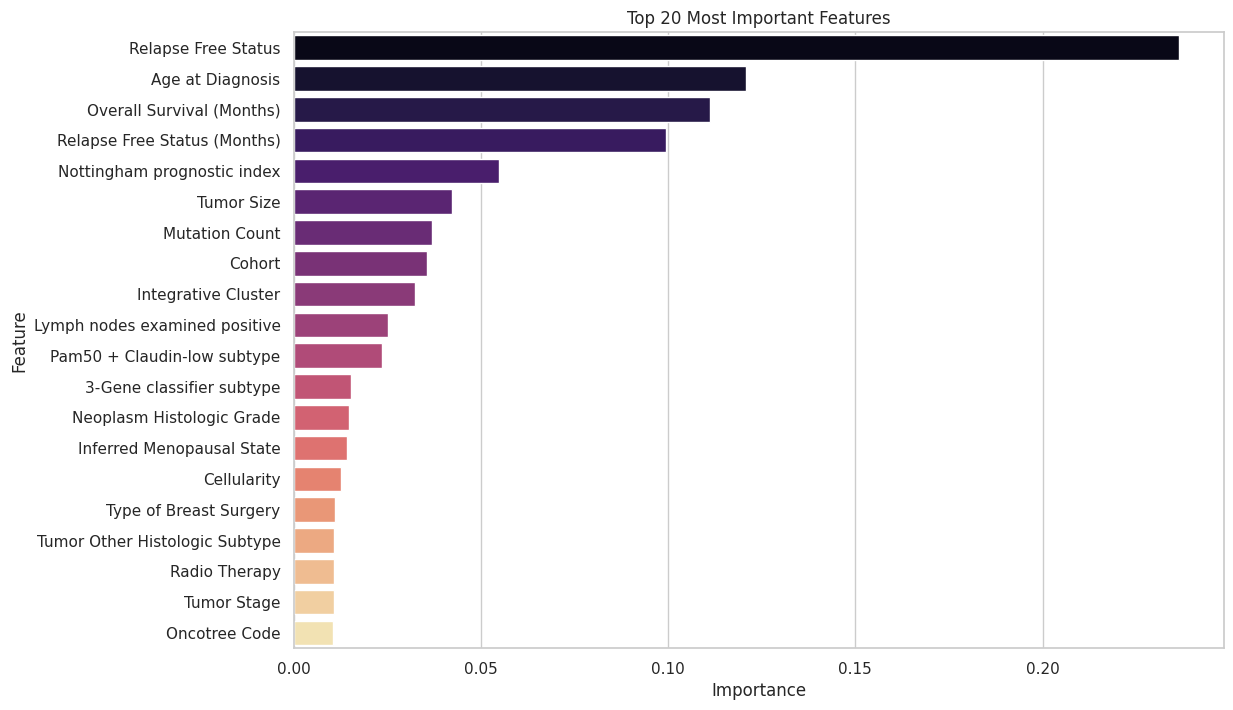

In [36]:
importances = rf_model.feature_importances_
feature_names = X.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False).head(20)

plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='magma')
plt.title('Top 20 Most Important Features')
plt.show()